# 3. How much any of this settles

Notebook 02 reported margins with p values and intervals attached. This notebook computes those two
quantities from scratch, next to the naive versions of themselves, because the difference between
them is large enough to change what the project claims.

Two things are demonstrated rather than asserted:

1. A plain paired t test over the fifty species differences returns p = 0.00008. The corrected test
   returns p = 0.25 on identical numbers.
2. Resampling clips rather than recordings returns an interval several times too narrow.

Both are run below on the committed predictions.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats

# Works whether the kernel starts in the repository root or in experiments/.
sys.path.insert(0, str(Path.cwd() if (Path.cwd() / "src").is_dir() else Path.cwd().parent))

from src import uncertainty
from src.config import load_config
from src.results import config_directory, model_directory, predictions_path

cfg = load_config("configs/base.yaml")
REPORT = config_directory(cfg)
pd.set_option("display.width", 160)


def scores(name):
    """One macro-F1 per split, indexed by (repeat, fold)."""
    return uncertainty.fold_scores(
        pd.read_csv(model_directory(cfg, name) / "fold_metrics_clip.csv")
    )


print(f"{cfg.split.n_folds} folds per split, grouped by {cfg.split.group_column}")

5 folds per split, grouped by tape_id


## 1. Fifty differences from the same fifty splits

The trees and the metadata control ran the identical fold plan, so their scores pair split by split.
`shared_folds` narrows two score series to the splits both were scored on, which matters when a five
fold network is compared against a fifty split control.

In [2]:
audio, floor = uncertainty.shared_folds(scores("xgboost"), scores("metadata"))
differences = (audio - floor).to_numpy()

print(f"{len(differences)} paired differences")
print(f"mean {differences.mean():+.4f}, standard deviation {differences.std(ddof=1):.4f}")
print(f"negative in {(differences < 0).sum()} of {len(differences)}")

pd.DataFrame({"audio": audio, "floor": floor, "difference": audio - floor}).head(10).round(4)

50 paired differences
mean -0.1154, standard deviation 0.1865
negative in 38 of 50


audio   floor  difference
repeat fold                            
0      0     0.7202  0.9813     -0.2611
       1     0.7033  1.0000     -0.2967
       2     0.6703  0.8509     -0.1806
       3     0.8075  0.6575      0.1500
       4     0.7130  0.9287     -0.2157
1      0     0.7103  0.7320     -0.0216
       1     0.7542  0.9966     -0.2424
       2     0.7508  0.8609     -0.1101
       3     0.8046  0.6575      0.1471
       4     0.7851  0.9474     -0.1624

## 2. The naive test, and why it is wrong here

A paired t test assumes the differences are independent. Treat them that way and the result looks
overwhelming.

They are not independent. Any two folds of a five fold split are fitted on training sets that share
three quarters of their data, and each repeat runs over the same clips again. So the differences are
correlated, and the ordinary standard error of the mean is far too small.

The corrected resampled test replaces `1/n` with `1/n + 1/(k-1)`, where `k` is the number of folds
per split. That inflates the variance by the amount the overlap warrants.

In [3]:
naive = stats.ttest_rel(audio.to_numpy(), floor.to_numpy())
corrected = uncertainty.paired_difference(audio, floor)

pd.DataFrame(
    [
        {
            "test": "plain paired t",
            "p_value": naive.pvalue,
            "resolves at 0.05": naive.pvalue < 0.05,
        },
        {
            "test": "corrected resampled",
            "p_value": corrected.p_value,
            "resolves at 0.05": corrected.resolved,
        },
    ]
)

,test,p_value,resolves at 0.05
0,plain paired t,0.000063,True
1,corrected resampled,0.239291,False


In [4]:
inflation = (1 / len(differences) + 1 / (cfg.split.n_folds - 1)) / (1 / len(differences))
print(f"variance inflation from the correction: {inflation:.1f} times")
print(f"standard error therefore {np.sqrt(inflation):.1f} times wider")
print()
print(corrected.describe())

variance inflation from the correction: 13.5 times
standard error therefore 3.7 times wider

0.115 lower [-0.310, +0.079], p = 0.239, not resolvable by this design, on 50 folds; the direction held in 38 of 50 folds


Same numbers, same direction, same fifty splits. One of those p values is a headline and the other
is nothing of the kind. Every p value in this project is the corrected one.

`tests/test_uncertainty.py` fails if repeating a split ever converts an unresolved comparison into a
resolved one, which is the failure the correction exists to prevent.

## 3. What the correction does to the whole set of comparisons

Applied across every comparison in this configuration, one resolves. The rest are directions rather
than results, and the `agreeing` column is worth reading where the p value settles nothing: a
direction holding in 44 of 50 splits is informative even when the test cannot separate it.

One caution on this file. Each family is measured against the control it declares, which for species
is the metadata model. The comparison that does resolve for species, XGBoost against the logbook at
p = 9.5e-09, is not in here, because the logbook is a member of that family rather than its declared
control. Notebook 02 computes it.

In [5]:
margins = pd.read_csv(REPORT / "family_margins.csv").sort_values("p_value")
margins["resolves"] = margins.p_value < 0.05
print(f"{margins.resolves.sum()} of {len(margins)} comparisons resolve at p < 0.05")
margins.round(4)

5 of 18 comparisons resolve at p < 0.05


,family,model,floor,margin,low,high,p_value,agreeing,folds,resolves
0,species,xgboost,logbook,-0.2450,-0.3181,-0.1720,0.0000,50,50,True
1,species,probe,logbook,-0.2583,-0.3525,-0.1642,0.0000,50,50,True
2,species,cnn_small,logbook,-0.2878,-0.4358,-0.1398,0.0003,50,50,True
3,calltype_spermwhale_coda,calltype_spermwhale_coda,calltype_spermwhale_coda_context,-0.1622,-0.3015,-0.0229,0.0234,46,50,True
4,species,cnn,logbook,-0.2848,-0.5136,-0.0560,0.0259,5,5,True
5,species,logbook,metadata,0.1296,-0.0123,0.2715,0.0724,45,50,False
6,calltype_killerwhale_click,calltype_killerwhale_click,calltype_killerwhale_click_context,0.1249,-0.0398,0.2897,0.1339,37,50,False
7,species,probe,metadata,-0.1287,-0.3049,0.0474,0.1484,39,50,False
8,calltype_spermwhale_coda,calltype_spermwhale_coda_cnn_small,calltype_spermwhale_coda_context,-0.2242,-0.6154,0.1669,0.1867,5,5,False
9,calltype_killerwhale_whistle,calltype_killerwhale_whistle,calltype_killerwhale_whistle_context,0.0446,-0.0232,0.1124,0.1923,36,50,False


## 4. The unit of independence

An interval answers a different question from a p value: how much would a different draw of
recordings have changed this score?

Cuts from one tape are near duplicates of each other, so a tape is one piece of evidence however many
clips it was cut into. Resampling tapes respects that. Resampling clips treats each near duplicate as
fresh evidence, and the interval collapses.

Both runs below use the same predictions, the same metric and the same number of resamples. Only the
group changes.

In [6]:
predictions = pd.read_parquet(predictions_path(cfg, "xgboost"))
predictions = predictions[predictions.repeat == 0].reset_index(drop=True)
print(f"{len(predictions)} clips over {predictions.tape_id.nunique()} tapes")

RESAMPLES = 300  # kept modest so the notebook runs inside the CI budget
names = list(cfg.dataset.species)

by_tape = uncertainty.bootstrap_metric(predictions, names, resamples=RESAMPLES, seed=0)

# The only change: every clip becomes its own group, so 134 recordings look like 4160.
as_clips = predictions.assign(tape_id=predictions.clip_id)
by_clip = uncertainty.bootstrap_metric(as_clips, names, resamples=RESAMPLES, seed=0)

pd.DataFrame(
    [
        {
            "resampled over": "tapes",
            "estimate": by_tape.estimate,
            "low": by_tape.low,
            "high": by_tape.high,
            "width": by_tape.width,
        },
        {
            "resampled over": "clips",
            "estimate": by_clip.estimate,
            "low": by_clip.low,
            "high": by_clip.high,
            "width": by_clip.width,
        },
    ]
).round(4)

4160 clips over 134 tapes


,resampled over,estimate,low,high,width
0,tapes,0.7265,0.6202,0.8311,0.2110
1,clips,0.7265,0.7098,0.7437,0.0339


In [7]:
print(f"resampling clips makes the interval {by_tape.width / by_clip.width:.1f} times narrower")
print(
    f"and it does so without adding a single recording: {predictions.tape_id.nunique()} either way"
)

resampling clips makes the interval 6.2 times narrower
and it does so without adding a single recording: 134 either way


The two intervals below are built from identical predictions. The narrow one is the one that would be
reported by anyone who forgot that clips from one recording are not independent observations.

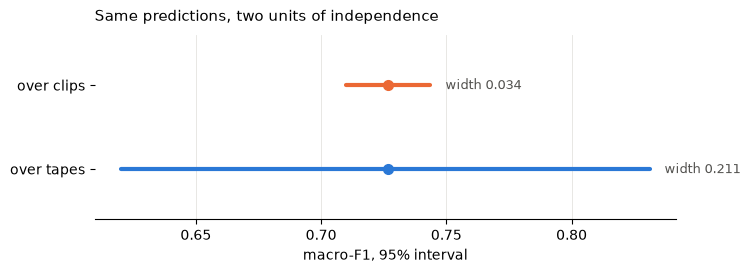

In [8]:
import matplotlib.pyplot as plt

from src.evaluate.plots import SERIES

%matplotlib inline

figure, ax = plt.subplots(figsize=(7.5, 2.4))
for row, interval in enumerate((by_tape, by_clip)):
    ax.plot(
        [interval.low, interval.high],
        [row, row],
        color=SERIES[row],
        linewidth=3,
        solid_capstyle="round",
    )
    ax.plot([interval.estimate], [row], "o", color=SERIES[row], markersize=7)
    ax.text(
        interval.high + 0.006,
        row,
        f"width {interval.width:.3f}",
        va="center",
        fontsize=9,
        color="#52514e",
    )

ax.set_yticks([0, 1], ["over tapes", "over clips"])
ax.set_ylim(-0.6, 1.6)
ax.set_xlabel("macro-F1, 95% interval")
ax.set_title("Same predictions, two units of independence", loc="left", fontsize=11, pad=10)
for spine in ("top", "right", "left"):
    ax.spines[spine].set_visible(False)
ax.grid(axis="x", color="#d8d7d2", linewidth=0.6, alpha=0.7)
ax.set_axisbelow(True)
plt.show()

## 5. Why the design is this small

The binding quantity is independent recordings, not clips. This configuration has 134 of them, and
one class survives on twelve.

That is why so little resolves. It is not that the effects are absent, it is that a design this size
cannot separate differences of the size being reported, and saying so is different from saying the
difference is zero.

In [9]:
fold_summary = pd.read_csv(REPORT.parent / f"fold_summary_{cfg.name}.csv")
held_out = fold_summary[fold_summary.part == "test"]
per_fold = held_out.pivot(index="fold", columns="species", values="tapes")
print(f"test tapes per class per fold, thinnest cell {int(per_fold.min().min())}")
per_fold

test tapes per class per fold, thinnest cell 1


species,HumpbackWhale,KillerWhale,SpermWhale
fold,,,
0,1,12,12
1,1,13,12
2,4,13,11
3,2,13,11
4,4,14,12


## What this notebook does not settle

The correction assumes the folds within a split overlap in the way `1/n + 1/(k-1)` describes. That is
the standard treatment for repeated cross validation and it is a correction rather than a cure: it
widens an interval that was too narrow, and it does not manufacture recordings that were never made.

The bootstrap resamples the tapes this collection happens to hold. It says what a different draw from
the same collection would have given, and nothing about a different collection.

Notebook 04 asks whether more recordings change the picture, using the eleven species the archive
holds rather than three.